In [1]:
# Load the CIFAR-10 dataset
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
# Show 10 images from the training set with their labels
import matplotlib.pyplot as plt
import numpy as np
# Load a pre-trained MobileNetV3 and inspect its structure
import torchvision.models as models
import torch.nn.functional as F
import torchvision.models as models
from torch import nn as nn
# metrics
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from fvcore.nn import FlopCountAnalysis

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
def load_data(batch_size, data_dir="data"):
    """Load the FCIFAR-10 dataset."""
    # Define transforms to normalize the data
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )
    # Download and load the training data
    trainset = datasets.CIFAR10(
        data_dir, download=True, train=True, transform=transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True
    )
    # Download and load the test data
    testset = datasets.CIFAR10(
        data_dir, download=True, train=False, transform=transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=True
    )

    return trainloader, testloader

In [4]:
# Define some helper functions to helps with the labels
def get_class_names():
    """Return the list of classes in the Fashion-MNIST dataset."""
    return [
        'airplane',
        'automobile',
        'bird',
        'cat',
        'deer',
        'dog',
        'frog',
        'horse',
        'ship',
        'truck'
    ]


def get_class_name(class_index):
    """Return the class name for the given index."""
    return get_class_names()[class_index]


def get_class_index(class_name):
    """Return the class index for the given name."""
    return get_class_names().index(class_name)


for class_index in range(10):
    print(f"class_index={class_index}, class_name={get_class_name(class_index)}")

class_index=0, class_name=airplane
class_index=1, class_name=automobile
class_index=2, class_name=bird
class_index=3, class_name=cat
class_index=4, class_name=deer
class_index=5, class_name=dog
class_index=6, class_name=frog
class_index=7, class_name=horse
class_index=8, class_name=ship
class_index=9, class_name=truck


In [5]:
# Define a model class that extends the nn.Module class
class MobileNetV3(nn.Module):
    def __init__(self):
        super(MobileNetV3, self).__init__()
        # Load the pre-trained MobileNetV3 (Small) architecture
        self.model = models.mobilenet_v3_small(pretrained=True)
        # Replace the last fully-connected layer with a new one of the right size
        self.model.classifier[3] = nn.Linear(1024, 10)
        # Freeze all the weights of the network except for the last fully-connected layer
        self.freeze()

    def forward(self, x):
        # Resize the input to 224x224, since MobileNetV3 (Small) expects images of that size
        if x.shape[2:] != (224, 224):
            x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

        # Forward pass
        return self.model(x)

    def freeze(self):
        # Freeze all the weights of the network except for the last fully-connected layer
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze the final layer
        for param in self.model.classifier[3].parameters():
            param.requires_grad = True

    def unfreeze(self):
        # Unfreeze all the weights of the network
        for param in self.model.parameters():
            param.requires_grad = True

In [6]:
# Load train, test
trainloader, testloader = load_data(64)
# Create an instance of the MobileNetV3 model
model = MobileNetV3()
# or load a trained model
'''
location_save = '/content/drive/MyDrive/epita/action-learning/model/'
PATH = '/'.join([location_save, 'mobilenet_transfer_v1.pth'])
model = MobileNetV3()
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval()
'''

# Define the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.002)

/opt/anaconda3/envs/example/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/example/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


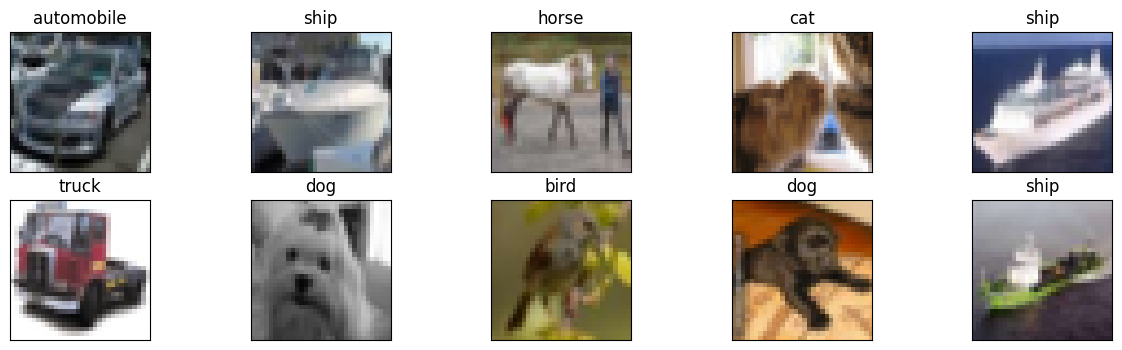

In [7]:
# function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()  # convert from tensor to numpy array
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # transpose dimensions


images, labels = next(iter(trainloader))  # get the first batch

# show images with labels
fig = plt.figure(figsize=(15, 4))
plot_size = 10

for idx in np.arange(plot_size):
    ax = fig.add_subplot(2, plot_size // 2, idx + 1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(get_class_name(int(labels[idx])))

In [8]:
# Set the device as GPU, MPS, or CPU according to availability
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [9]:
# Create a PyTorch training loop
model = model.to(device)  # Move the model weights to the device

epochs = 30
for epoch in range(epochs):
    for batch_num, (images, labels) in enumerate(trainloader):
        # Move tensors to the device
        images = images.to(device)
        labels = labels.to(device)

        # Zero out the optimizer's gradient buffer
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate the loss and perform backprop
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Update the weights
        optimizer.step()

        # Print the loss for every 100th iteration
        if (batch_num) % 100 == 0:
            print(
                "Epoch [{}/{}], Batch [{}/{}], Loss: {:.4f}".format(
                    epoch + 1, epochs, batch_num + 1, len(trainloader), loss.item()
                )
            )

Epoch [1/30], Batch [1/782], Loss: 2.3485
Epoch [1/30], Batch [101/782], Loss: 0.8053
Epoch [1/30], Batch [201/782], Loss: 0.7307
Epoch [1/30], Batch [301/782], Loss: 0.5827
Epoch [1/30], Batch [401/782], Loss: 0.6022
Epoch [1/30], Batch [501/782], Loss: 0.6502
Epoch [1/30], Batch [601/782], Loss: 0.5002
Epoch [1/30], Batch [701/782], Loss: 0.5737
Epoch [2/30], Batch [1/782], Loss: 0.6268
Epoch [2/30], Batch [101/782], Loss: 0.6008
Epoch [2/30], Batch [201/782], Loss: 0.5177
Epoch [2/30], Batch [301/782], Loss: 0.2899
Epoch [2/30], Batch [401/782], Loss: 0.5800
Epoch [2/30], Batch [501/782], Loss: 0.4991
Epoch [2/30], Batch [601/782], Loss: 0.5670
Epoch [2/30], Batch [701/782], Loss: 0.6382
Epoch [3/30], Batch [1/782], Loss: 0.3237
Epoch [3/30], Batch [101/782], Loss: 0.3911
Epoch [3/30], Batch [201/782], Loss: 0.6085
Epoch [3/30], Batch [301/782], Loss: 0.3941
Epoch [3/30], Batch [401/782], Loss: 0.3602
Epoch [3/30], Batch [501/782], Loss: 0.5958
Epoch [3/30], Batch [601/782], Loss: 0

In [10]:
# Print the loss and accuracy on the test set
correct = 0
total = 0
loss = 0

for images, labels in testloader:
    # Move tensors to the configured device
    images = images.to(device)
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)
    loss += loss_fn(outputs, labels)

    # torch.max return both max and argmax. We get the argmax here.
    _, predicted = torch.max(outputs.data, 1)

    # Compute the accuracy
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(
    "Test Accuracy of the model on the test images: {} %".format(100 * correct / total)
)
print("Test Loss of the model on the test images: {}".format(loss))

Test Accuracy of the model on the test images: 81.44 %
Test Loss of the model on the test images: 87.2614517211914


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6784314..0.79607844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6862745..0.78039217].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81960785..0.8039216].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8745098..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.88235295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8509804..0.7

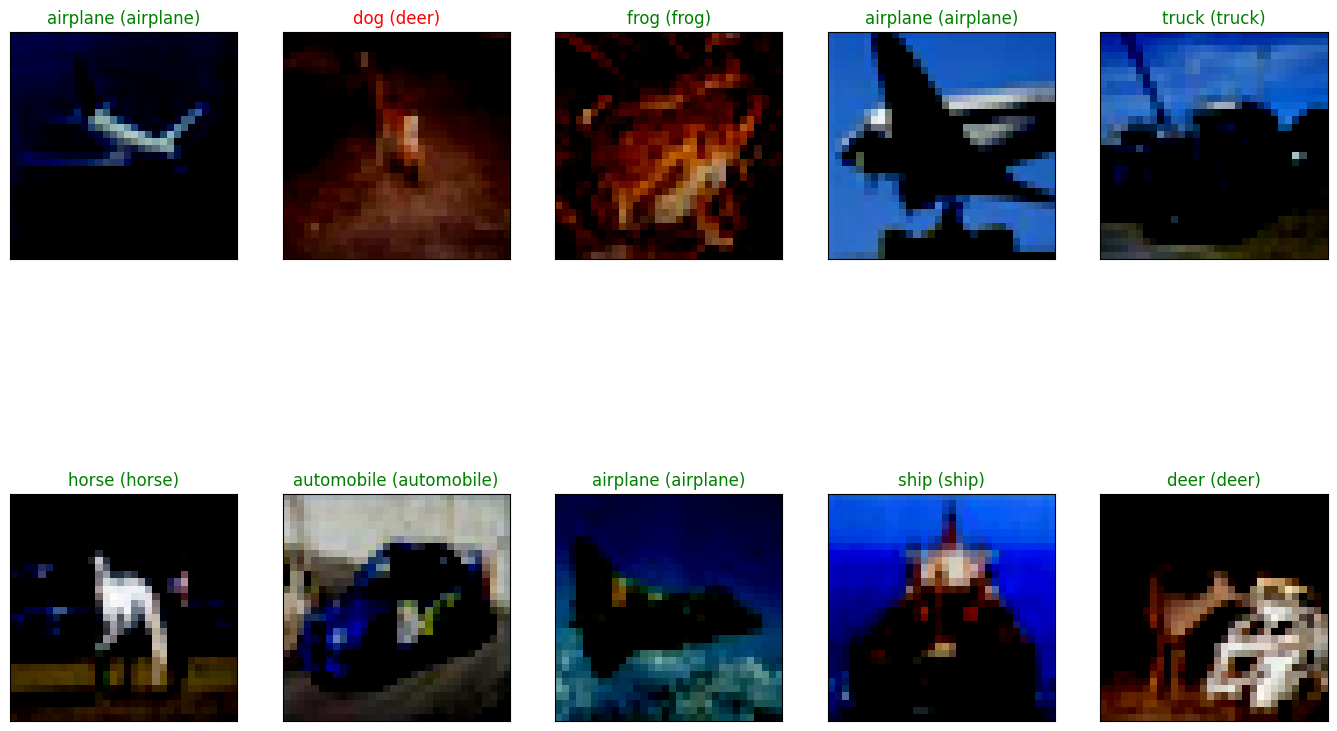

In [11]:
# Get the first batch of images and labels
images, labels = next(iter(testloader))

# Move tensors to the configured device
images = images.to(device)
labels = labels.to(device)

# Forward pass
outputs = model(images)
_, predicted = torch.max(outputs.data, 1)

# Plot the images with labels, at most 10
fig = plt.figure(figsize=(17,11))

for idx in np.arange(min(10, len(images))):
    ax = fig.add_subplot(2, 10 // 2, idx + 1, xticks=[], yticks=[])
    ax.imshow(np.transpose(np.squeeze(images.cpu()[idx]), (1, 2, 0)))
    ax.set_title(
        "{} ({})".format(get_class_name(predicted[idx]), get_class_name(labels[idx])),
        color=("green" if predicted[idx] == labels[idx] else "red"),
    )

In [12]:
# Get the first batch of images and labels
images, labels = next(iter(testloader))

y_true = np.array(1)
y_pred = np.array(1)

for images, labels in testloader:
# Move tensors to the configured device
    images = images.to(device)
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    # get y_true and y_pred
    y_true = np.append(y_true, labels.cpu().numpy())
    y_pred = np.append(y_pred, predicted.cpu().numpy())

In [13]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1-Score (macro, micro, weighted)
precision = precision_score(y_true, y_pred, average='macro')  # Options: 'micro', 'weighted', 'macro'
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Accuracy: 0.82
Precision: 0.82
Recall: 0.82
F1-Score: 0.82


In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_count = count_parameters(model)
print(f"Number of parameters: {param_count}")

Number of parameters: 10250


In [15]:
# Example input shape (batch_size=1, channels=3, height=224, width=224)
input_tensor = torch.randn(1, 3, 224, 224).to(device)

flops = FlopCountAnalysis(model, input_tensor)
print(f"FLOPs: {flops.total()}")

Unsupported operator aten::add_ encountered 40 time(s)
Unsupported operator aten::hardswish_ encountered 19 time(s)
Unsupported operator aten::hardsigmoid encountered 9 time(s)
Unsupported operator aten::mul encountered 9 time(s)
Unsupported operator aten::dropout_ encountered 1 time(s)


FLOPs: 62874080


In [16]:
save_folder = '/Users/jatinkumarparmar/Desktop/Action Learning/1_Code'

# Save the state_dict only.
torch.save(model.state_dict(), '/'.join([save_folder, 'mobilenet_transfer_v1.pth']))

In [17]:
result = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'param_count': param_count,
    'flops': flops.total(),
    'loss': loss.item()
}

import json
with open('/'.join([save_folder, 'mobilenet_transfer_v1.json']), 'w') as f:
    json.dump(result, f)

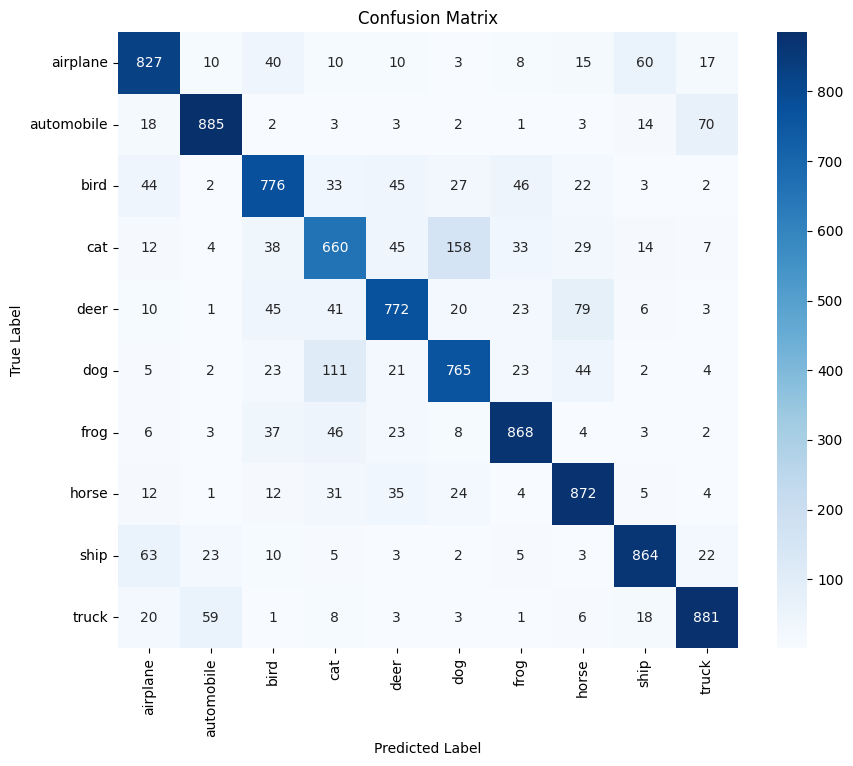

In [18]:
# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=get_class_names(), yticklabels=get_class_names())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig('/'.join([save_folder, 'mobilenet_transfer_v1_confusion_matrix.png']))
plt.show()

In [19]:
# # Code to load it again
# '''
# location_save = '/content/drive/MyDrive/epita/action-learning/model/'
# PATH = '/'.join([location_save, 'mobilenet_transfer_v1.pth'])
# model_load = MobileNetV3()
# model_load.load_state_dict(torch.load(PATH, weights_only=True))
# model_load.eval()
# '''

# PTQ

In [30]:
import os
import time

In [31]:
# Load model

location_save = '/Users/jatinkumarparmar/Desktop/Action Learning/1_Code'
PATH = '/'.join([location_save, 'mobilenet_transfer_v1.pth'])
model = MobileNetV3()
model.load_state_dict(torch.load(PATH, weights_only=True, map_location=torch.device('cpu')))
model.eval()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.002)

In [32]:
# Set quantization backend
torch.backends.quantized.engine = 'qnnpack'
model.cpu()

# Apply dynamic quantization
quantized_model = torch.quantization.quantize_dynamic(
    model, {nn.Linear, nn.Conv2d}, dtype=torch.qint8
)

In [33]:
# Function to print model size
def model_size(model, label=""):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p")
    print("Model:", label, '\t', 'Size (KB):', size/1e3)
    os.remove('temp.p')
    return size

In [34]:
# Compare model sizes
f_size = model_size(model, "fp32")
q_size = model_size(quantized_model, "int8")
print(f"{f_size/q_size:.2f} times smaller")

Model: fp32 	 Size (KB): 6234.793
Model: int8 	 Size (KB): 4436.053
1.41 times smaller


In [35]:
# Function to measure latency
def measure_latency(model, inputs, num_trials=100):
    model.eval()
    total_time = 0
    with torch.no_grad():
        for _ in range(num_trials):
            start = time.time()
            _ = model(inputs)
            total_time += time.time() - start
    return total_time / num_trials

In [36]:
# Measure latency
sample_input = torch.randn(1, 3, 32, 32)
fp32_latency = measure_latency(model, sample_input)
print(f"Average FP32 latency: {fp32_latency:.6f} seconds")
int8_latency = measure_latency(quantized_model, sample_input)
print(f"Average Quantized INT8 latency: {int8_latency:.6f} seconds")

Average FP32 latency: 0.032383 seconds
Average Quantized INT8 latency: 0.032060 seconds


In [37]:
def evaluate_model(model, testloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images = images.cpu()
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())
    accuracy = accuracy_score(y_true, y_pred)
    return accuracy, y_true, y_pred

In [38]:
# Evaluate accuracy
print("\nEvaluating accuracy...")
fp32_accuracy, _, _ = evaluate_model(model, testloader)
int8_accuracy, y_true, y_pred = evaluate_model(quantized_model, testloader)
print(f"FP32 Accuracy: {fp32_accuracy:.4f}")
print(f"INT8 Accuracy: {int8_accuracy:.4f}")
print(f"Accuracy drop: {(fp32_accuracy - int8_accuracy):.4f}")


Evaluating accuracy...
FP32 Accuracy: 0.7668
INT8 Accuracy: 0.7658
Accuracy drop: 0.0010


In [43]:
# Calculate metrics for the quantized model
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7658
Precision: 0.7766
Recall: 0.7658
F1-Score: 0.7652


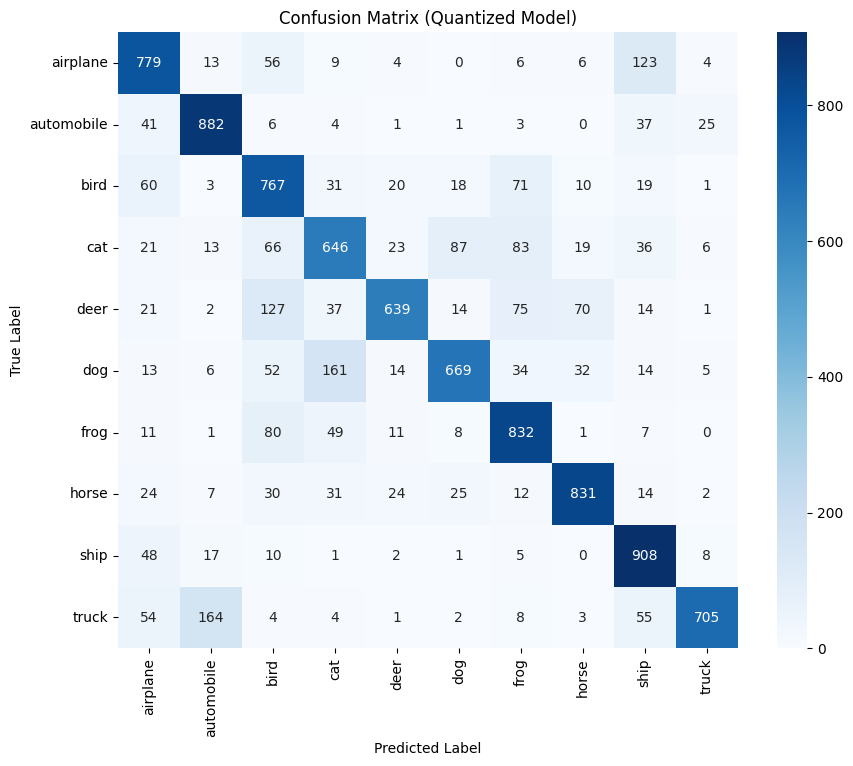

In [40]:
# Plot confusion matrix for quantized model
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=get_class_names(), yticklabels=get_class_names())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Quantized Model)")
plt.show()